<center>
 <p>116 Advanced Statistics</p>
 <h1></h1>
 <h1>Lecture 10: Bootstrap and shuffle </h1>
 <p>----</p>
 <p>Prof. Jochen Braun Ph.D.</p>
 <p>Institute of Biology</p>
 <p>Otto-von-Guericke University Magdeburg</p>
 <p>----</p>
 <p>Textbook:</p>
 <p> B Efron & T Hastie (2016) Computer Age Statistical Inference, </p>
 <p> Cambridge University Press.</p>
</center>

# **Abstract:**

This lecture introduces computer-intensive **permutational methods**, in particular **bootstrapping** for estimating standard errors and confidence intervals, and **shuffling** to generate null distributions.

The following lectures will apply these important methods to additional practical examples.




# **Overview:**


**1. Bootstrapping for standard error and confidence**

**2. Bootstrapping standard errors in logistic regression**

**3. Shuffling for null distributions**

**4. Null distributions for entropy**





# **1. Bootstrapping for standard error and confidence**

Often we have a (smallish) set of observations ${\bf x} = (x_1, x_2, \ldots , x_n)$ from some unknown probability distribution $F$

$$
x_i \sim F\qquad\qquad i = 1, 2, \ldots, n
$$

and have estimated a (real-valued) statistic $\theta$ with some algorithm or procedure $s({\bf x})$

$$
\theta = s({\bf x})
$$

Note that this situation is quite general: the samples $x_i$ can be univariate, bivariate, multivariate, the distribution is not restricted to any parametric family, and the algorithm $s({\bf x})$ can be anything.

<br>

So is there any way to estimate the standard error of our estimate $theta$, in other words, the standard deviation that we would expect to observe if (counterfactually) we were able to repeat our experiment many times?

<br>

Suprisingly, there is a simple (albeit computationally intensive) familiy of solutions for this problem, which are known collectively as **bootstrapping**.



# Jackknife estimate

This is a versatile and handy tool for many situations, much like a pocket knife or jackknife.

<br>

Let's remove one observation, $x_i$, from our sample ${\bf x}$, and denote with ${\bf x}_{(i)}$ the smaller sample that results  

$$
{\bf x}_{(i)} = (x_1, \ldots , x_{i-1}, x_{i+1}, \ldots , x_n)
$$

and with $\theta_{(i)}$ the corresponding value of our statistic

$$
\theta_{(i)} = s({\bf x}_{(i)})
$$

<br>

The Jackknife estimate for standard error is

$$
\mathrm{se}_\mathit{jack} = \left[ \frac{n-1}{n} \sum_{i=1}^n \left(\theta_{(i)}-\theta_{(\cdot)} \right)^2 \right]^{1/2}, \qquad\qquad \theta_{(\cdot)} = \frac{1}{n} \sum_{i=1}^n \theta_{(i)}
$$

<br>

As a transparent example, consider the case when $\theta=s(x)$ is simply the mean of real-valued $x_i$

$$
\theta = \bar x = \frac{1}{n} \sum_i x_i, \qquad\qquad \theta_{(i)}= \frac{n \bar x - x_i}{n-1}
$$

In this case, the average and the deviation from the average are

$$
\theta_{(\cdot)} = \frac{1}{n}\sum_i \theta_{(i)} = \frac{n \bar x}{n-1}- \frac{\bar x}{n-1} = \bar x, \qquad\qquad \theta_{(i)}-\theta_{(\cdot)}=\frac{n \bar x - x_i}{n-1} - \frac{\bar x(n-1)}{n-1} = \frac{\bar x - x_i}{n-1}
$$

and the Jackknife estimate

$$
\mathrm{se}_\mathit{jack} = \left[ \frac{n-1}{n} \sum_{i=1}^n \left(\theta_{(i)}-\theta_{(\cdot)} \right)^2 \right]^{-1/2} = \left[ \frac{1}{n(n-1)} \sum_{i=1}^n \left(x_i - \bar x \right)^2 \right]^{-1/2}
$$

equals the classical standard error for normally distributed samples.

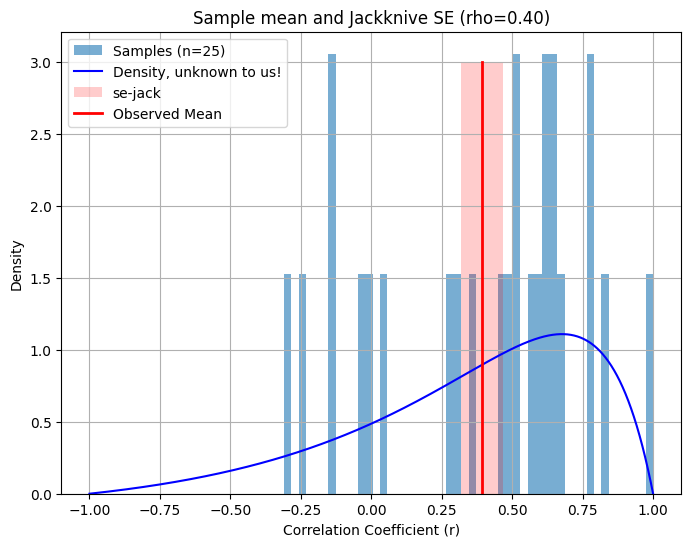

In [ ]:
# @title Jackknife example, sampling from Fisher's correlation density {"vertical-output":true,"display-mode":"form"}

import numpy as np
from scipy.special import gamma, beta, hyp2f1
import matplotlib.pyplot as plt
from scipy.stats import norm

def jackknife_mean_error(data):
    """
    Compute the Jackknife standard error estimate for the sample mean.

    Parameters:
    data : array-like, input sample data

    Returns:
    se_jack : float, Jackknife standard error estimate
    mean : float, sample mean
    jack_means : array, leave-one-out means
    """
    # Convert input to numpy array
    data = np.array(data)
    n = len(data)

    if n < 2:
        raise ValueError("Sample size must be at least 2 for Jackknife estimation.")

    # Compute original sample mean
    mean = np.mean(data)

    # Compute leave-one-out means
    jack_means = np.zeros(n)
    for i in range(n):
        # Mean of data excluding i-th observation
        jack_means[i] = np.mean(np.delete(data, i))

    # Compute Jackknife standard error
    se_jack = np.sqrt((n - 1) / n * np.sum((jack_means - np.mean(jack_means))**2))

    return se_jack, mean, jack_means

def correlation_density_rho(r, rho, n):
    """
    Compute the probability density function of the Pearson correlation coefficient r
    for a sample size n and population correlation rho, as derived by R.A. Fisher.

    Parameters:
    r : float or array-like, correlation coefficient(s) in [-1, 1]
    rho : float, population correlation coefficient in (-1, 1)
    n : int, sample size (n >= 3)

    Returns:
    density : float or array-like, the density f(r | rho, n) at the given r
    """
    if n < 3:
        raise ValueError("Sample size n must be at least 3.")
    if not -1 < rho < 1:
        raise ValueError("Population correlation rho must be in (-1, 1).")

    # Ensure r is in [-1, 1]
    r = np.clip(r, -1, 1)

    # Constants
    term1 = (n - 2) * gamma(n - 1) / (np.sqrt(2 * np.pi) * gamma(n - 0.5))
    term2 = (1 - rho**2)**((n - 1) / 2)
    term3 = (1 - r**2)**((n - 4) / 2)
    term4 = (1 - rho * r)**(3/2 - n)

    # Hypergeometric function _2F_1(1/2, 1/2; (2n-3)/2; (rho*r + 1)/2)
    hypergeom = hyp2f1(0.5, 0.5, (2 * n - 3) / 2, (rho * r + 1) / 2)

    # Combine terms
    density = term1 * term2 * term3 * term4 * hypergeom

    # Handle numerical stability (avoid NaNs or negative densities)
    density = np.where(np.isfinite(density), density, 0)

    return density

def sample_correlated_pairs( x, y, num_samples=1):
    """
    Generate synthetic observations, returned in r_sample
    For this purpose, sample the provided list of pairs with replacement
    The correlation coefficient of bootstrapped lists of pairs
    provides a synthetic observation

    Don't be confused that bootstrapping is used twice:
    Once for sample generation (in this function)
    Again to evaluate the SE of the sample averate (Jackknife, Bootstrap)
    """

    if n < 3:
        raise ValueError("Sample size n must be at least 3.")
    if not -1 < rho < 1:
        raise ValueError("Population correlation rho must be in (-1, 1).")


    r_unclean = np.zeros(num_samples)

    for i in range(num_samples):

        # Randomly sample indices with replacement
        sampled_indices = np.random.choice(n, size=n, replace=True)

        # Extract sampled elements
        sampled_x = x[sampled_indices]
        sampled_y = y[sampled_indices]

        r_unclean[i] = np.corrcoef(sampled_x, sampled_y)[0, 1]

    r_sample = r_unclean[~np.isnan(r_unclean)]

    return r_sample

def generate_correlated_pairs(n, rho, mu_x=0, mu_y=0, sigma_x=1, sigma_y=1):
    """
    Generate n pairs (x_i, y_i) from a bivariate normal distribution with correlation rho.

    Parameters:
    n : int, number of sample pairs
    rho : float, desired correlation coefficient in (-1, 1)
    mu_x : float, mean of X (default: 0)
    mu_y : float, mean of Y (default: 0)
    sigma_x : float, standard deviation of X (default: 1)
    sigma_y : float, standard deviation of Y (default: 1)
    random_seed : int, seed for reproducibility (default: None)

    Returns:
    x : array, x-coordinates of the sample pairs
    y : array, y-coordinates of the sample pairs
    sample_rho : float, observed correlation of the generated pairs
    """
    if n < 1:
        raise ValueError("Sample size n must be at least 1.")
    if not -1 < rho < 1:
        raise ValueError("Correlation rho must be in (-1, 1).")
    if sigma_x <= 0 or sigma_y <= 0:
        raise ValueError("Standard deviations must be positive.")

    # Define covariance matrix
    cov_matrix = np.array([[sigma_x**2, rho * sigma_x * sigma_y],
                           [rho * sigma_x * sigma_y, sigma_y**2]])

    # Cholesky decomposition: cov_matrix = L @ L.T
    L = np.linalg.cholesky(cov_matrix)

    # repeat in order to get close to desired rho
    Ntry = 1000

    x = np.empty((Ntry,n))
    y = np.empty((Ntry,n))
    sample_rho = np.empty(Ntry)

    for i in range(Ntry):

        # Generate independent standard normal variables
        Z = np.random.normal(0, 1, size=(n, 2))

        # Transform to correlated variables: W = L @ Z.T
        W = (L @ Z.T).T  # Shape: (n, 2)

        # Add means
        x[i,:] = mu_x + W[:, 0]
        y[i,:] = mu_y + W[:, 1]

        # Compute observed correlation
        sample_rho[i] = np.corrcoef(x[i,:], y[i,:])[0, 1]

    # select sample nearest to desired rho
    rho_deviation = np.abs(sample_rho - rho)
    ixclose = np.where( rho_deviation == np.min(rho_deviation))[0]

    ix = ixclose[0]

    return x[ix,:], y[ix,:], sample_rho[ix]

# Example usage: Draw samples and plot histogram for n=5, rho=0.5
if __name__ == "__main__":

    # Parameters
    n = 6
    rho = 0.4
    num_samples = 25

    # generate list of correlated value pairs, with sample_rho near rho
    (x, y, sample_rho) = generate_correlated_pairs(n, rho)

    # Draw samples
    samples = sample_correlated_pairs(x, y, num_samples)

    # observed sample mean
    sample_mean = np.mean(samples)

    (se_jack, mean, jack_means) = jackknife_mean_error( samples );

    ymax = 3

    xbox = sample_mean + se_jack * np.array([-1, 1, 1, -1]);
    ybox = ymax * np.array([0, 0, 1, 1]);

    # Compute theoretical density for comparison
    r_values = np.linspace(-1, 1, 1000)
    density = correlation_density_rho(r_values, sample_rho, n)

    # Plot histogram of samples and theoretical density
    plt.figure(figsize=(8, 6))
    plt.hist(samples, bins=50, density=True, alpha=0.6, label=f'Samples (n={num_samples})')
    plt.plot(r_values, density, 'b-', label='Density, unknown to us!')
    plt.fill(xbox, ybox, 'r', alpha=0.2, label='se-jack')
    plt.plot([sample_mean,sample_mean], [0,ymax], 'r-', linewidth=2, label='Observed Mean')
    plt.title(f"Sample mean and Jackknive SE (rho={sample_rho:.2f})")
    plt.xlabel('Correlation Coefficient (r)')
    plt.ylabel('Density')
    plt.grid(True)
    plt.legend()


# Nonparametric bootstrap

We stay with our general problem of a smallish set of observations ${\bf x} = (x_1, x_2, \ldots , x_n)$ from some unknown probability distribution $F$

$$
x_i \sim F\qquad\qquad i = 1, 2, \ldots, n
$$

for which we have estimated a statistic $\theta$ with some algorithm or procedure $s({\bf x})$

$$
\theta = s({\bf x})
$$

<br>

Bootstrapping approximates the unknown distribution $F$ by generating from our on original sample many **bootstrap samples**

$$
{\bf x}^* = (x_1^*, x_2^*, \ldots , x_n^*)
$$

by simply drawing each $x_i^*$ randomly (with equal probability and with replacement) from $(x_1, x_2, \ldots , x_n)$. From each bootstrap sample, we obtain a bootstrap replicate for our statistic $\theta$

$$
\theta_{b} = s\left({\bf x}^{*}_{b} \right), \qquad\qquad b = 1, 2, \ldots , B
$$

where $b$ indexes the $B$ repetitions of our boostrap. The boostrap standard error is then

$$
\mathrm{se}_\mathit{boot} = \left[ \frac{1}{B-1} \sum_{b=1}^B \left(\theta_{b}-\theta_{(\cdot)} \right)^2 \right]^{-1/2}, \qquad\qquad \theta_{(\cdot)} = \frac{1}{B} \sum_{b=1}^B \theta_{b}
$$


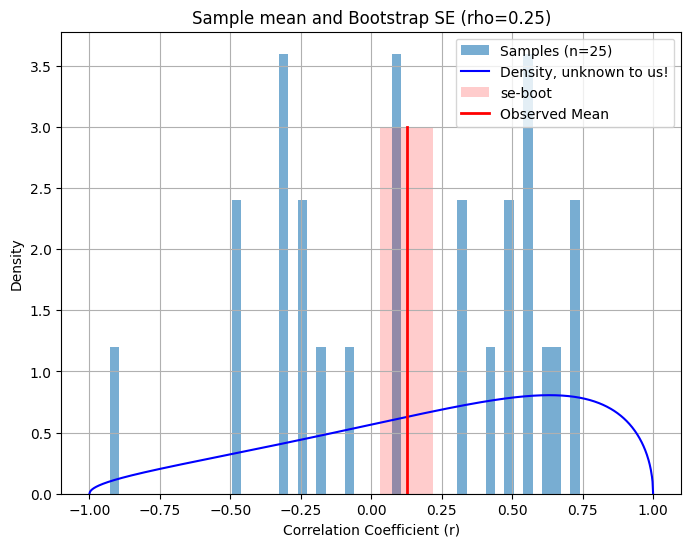

In [ ]:
# @title Bootstrap example, again with Fisher's correlation density {"vertical-output":true,"display-mode":"form"}

import numpy as np
from scipy.special import gamma, beta, hyp2f1

def bootstrap_mean_error(data, num_bootstrap=1000):
    """
    Compute the bootstrap standard error estimate for the sample mean.

    Parameters:
    data : array-like, input sample data
    num_bootstrap : int, number of bootstrap samples (default: 1000)
    random_seed : int, seed for reproducibility (default: None)

    Returns:
    se_boot : float, bootstrap standard error estimate
    mean : float, sample mean
    boot_means : array, means of bootstrap samples
    """
    # Convert input to numpy array
    data = np.array(data)
    n = len(data)

    if n < 2:
        raise ValueError("Sample size must be at least 2 for bootstrap estimation.")
    if num_bootstrap < 1:
        raise ValueError("Number of bootstrap samples must be at least 1.")

    # Compute original sample mean
    mean = np.mean(data)

    # Generate bootstrap samples and compute their means
    boot_means = np.zeros(num_bootstrap)
    for b in range(num_bootstrap):
        # Sample with replacement
        boot_sample = np.random.choice(data, size=n, replace=True)
        # Compute mean of bootstrap sample
        boot_means[b] = np.mean(boot_sample)

    # Compute bootstrap standard error (standard deviation of bootstrap means)
    se_boot = np.std(boot_means, ddof=1)

    return se_boot, mean, boot_means

# Example usage: Draw samples and plot histogram for n=5, rho=0.5
if __name__ == "__main__":
    import matplotlib.pyplot as plt

    # Parameters
    n = 5
    rho = 0.25
    num_samples = 25

    # generate correlated pairs, for synthetic observations
    (x, y, sample_rho) = generate_correlated_pairs(n, rho)

    # Generate synthetic observations
    samples = sample_correlated_pairs(x, y, num_samples)

    # observed sample mean
    sample_mean = np.mean(samples)

    # Compute bootstrap standard error for observed sample mean
    se_boot, mean, boot_means = bootstrap_mean_error(samples, num_bootstrap=1000)

    ymax = 3

    xbox = sample_mean + se_boot * np.array([-1, 1, 1, -1]);
    ybox = ymax * np.array([0, 0, 1, 1]);

    # Compute theoretical density for comparison
    r_values = np.linspace(-1, 1, 1000)
    density = correlation_density_rho(r_values, sample_rho, n)

    # Plot histogram of samples and theoretical density
    plt.figure(figsize=(8, 6))
    plt.hist(samples, bins=50, density=True, alpha=0.6, label=f'Samples (n={num_samples})')
    plt.plot(r_values, density, 'b-', label='Density, unknown to us!')
    plt.fill(xbox, ybox, 'r', alpha=0.2, label='se-boot')
    plt.plot([sample_mean,sample_mean], [0,ymax], 'r-', linewidth=2, label='Observed Mean')
    plt.title("Sample mean and Bootstrap SE")
    plt.title(f"Sample mean and Bootstrap SE (rho={sample_rho:.2f})")
    plt.xlabel('Correlation Coefficient (r)')
    plt.ylabel('Density')
    plt.grid(True)
    plt.legend()


# Resampling plans

If our sample size $n$ is very small, the number of possible Bootstrap samples is also small.  For example, if there are $n=4$ samples, there are $N_\mathit{boot}=35$ possible bootstrapped samples (drawn randomly with replacement). If there are only $n=3$ samples, there are only $N_\mathit{boot}=10$ bootstrapped samples. In general, we have

<br>

$$
N_\mathit{boot} = \binom{2n-1}{n}
$$

<br>

Of course, as sample size grows larger, the number bootstrapped sample becomes impractical quickly: $92,378$ for $n=10$ and $6.9\times 10^{10}$ for $n=20$. So how can we ensure that a smallish number of bootstrapped samples is an unbiased representation of the full ensemble?



# Aside: Multinomial distribution and simplex space

Assume that we take a set of $n$ samples from a random variable with $L$ alterative outcomes and associated probabilities

$$
{\boldsymbol \pi} = \{ \pi_1, \pi_2, \ldots , \pi_L\}, \qquad \sum_i \pi_i = 1
$$

Every possible set of samples is a vector of counts $k_i$

$$
{\bf k} = \{ k_1, k_2, \ldots , k_L\}, \qquad \sum_i k_i = n
$$

which lists how many times we sampled each outcome from $1$ to $L$ (outcome $x_1$ sampled $k_1$ times, and so on).


The probability of each set is given by the multinomial distribution

$$
f_{\boldsymbol \pi}({\bf x}) = \frac{n!}{k_1! \ldots k_L!}  \prod_{l=1}^{L} \pi_l^{k_l}
$$

<br>

For example, if our set comprises four samples, each with three possible outcomes, all possible sets are depicted in this simplex space:

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/EF_Fig_5_5.png" width="500">

$(k_1, k_2, k_3)$ in our notation ...


# Unbiased resampling

Our goal is to resample our original set of observations ${\bf x} = \{ x_1, x_2, \ldots , x_n\}$ in an unbiased way.


<br>

To this end, we define a resampling vector as a set of non-negative weights summing to unity

$$
{\bf P} = (P_1, P_2, \ldots, P_n), \qquad\qquad P_i \geq 0, \qquad \sum_{i=1}^{n} P_i = 1
$$

In other words, we consider *all of* our $n$ original observations ${\bf x}$, but change the probabilistic weights ${\bf P}$.


<br>

Any statistic $S({\bf x})$ is applied to a probabilistically resampled version of the original sample $\bf x$:

$$
\theta^* = S({\bf x}^*), \qquad\qquad {\bf x}^* = (P_1 x_1, P_2 x_2, \ldots , P_n x_n)
$$

For example, when our statistic is the arithmetic mean, we would use

$$
\theta^* = \frac{1}{n} \sum_i P_i x_i
$$

and when it is the true variance, we would use

$$
\theta^* = \frac{1}{n} \sum_i P_i (x_i-\mu_x)^2
$$

where $\mu_x$ is the true mean.

<br>

While this very general formulation is helpful for conceptual clarity, we will not use all of this generality in practice!



# Resampling vectors and associated probabilties

How do we choose resampling vectors $\bf P$ in an unbiased way, such as to accurately estimate the ensemble mean with reasonably small numbers of resampling, such as $B=200$?



The answer is to construct resampling vectors from count vectors which sum to $n$

$$
{\bf k} = \{ k_1, k_2, \ldots , k_L\}, \qquad \sum_i k_i = n
$$


and to assign to each count vector the associated multinomial probability:

$$
f_{\boldsymbol \pi}({\bf k}) = \frac{n!}{k_1! \ldots k_L!}  \prod_{l=1}^{n} \pi_l^{k_l} = \frac{n!}{k_1! \ldots k_n!}  \frac{1}{L^n}, \qquad {\boldsymbol \pi} = \left\{\frac{1}{L}, \ldots , \frac{1}{L} \right\}
$$


<br>

For example, if we start from $n=3$ observed samples, $x_1, x_2, x_3$, we want to generate bootstrap samples which also comprise $n=3$ samples. Count vectors $\bf k$ thus also have three elements, $k_1$, $k_2$, $k_3$, specifying the composition of a boostrap sample. There are ten possible compositions of bootstrap samples

$$
\begin{array}{cc}
\bf k = & (0,0,3) \\
 & (0,3,0) \\
 & (3,0,0) \\
  & (1,2,0) \\
 & (1,0,2) \\
  & (0,1,2) \\
 & (0,2,1) \\
   & (1,0,2) \\
 & (2,0,1)
\end{array}
$$

The associated bootstrap probabilities are

$$
P_{111} = \frac{3!}{1! 1! 1!}  \frac{1}{3^3} = \frac{6}{27}, \qquad P_{012} = \frac{3!}{0! 1! 2!}  \frac{1}{3^3} = \frac{3}{27},\qquad P_{003} = \frac{3!}{0! 0! 3!}  \frac{1}{3^3} = \frac{1}{27}
$$


Thus, if we `sample' from all possible boostrap samples with these probabilities, the result will be accurately represent the full ensemble.

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_sampling_simplex.png" width="500">

# Confidence intervals

To obtain confidence intervals, we can generate a larger number of ($B=5000 \to 20000$) of bootstrapped samples ${\bf x}^*$ and corresponding statistics $\theta^*$.

<br>

Sorting these statistics from the smallest to the largest value, we can identify the $\alpha/2$ level confidence tails. The $B \alpha / 2$ smallest values are the low tail, and the $B \alpha / 2$ larger values are the high tail.

<br>

The code below uses $B=5000$ and $\alpha=0.05$ so that both low and high tail comprise $125$ values each. The corresponding distribution bins are shown in red.

<br>

In this particular example, the distribution from which our samples are drawn is known analytically (Fisher's correlation density) and the sample values are correlation coefficients. Accordingly, we can use Fisher's z-transform

$$
z = \frac{1}{2} \log\frac{1+r}{1-r} = \mathrm{arctanh}(r)
$$

to obtain transformed values that are (very nearly) normally distributed, as illustrated by the second plot. This allows us to check our bootstrapped confidence interval by comparing it to the confidence interval of the normal distribution. As expected, everything matches quite well!

<br>

The samples of correlations coefficients are computed from $n$ pairs of observations. The average correlation is $\rho$. We can control the shape of the distribution of correlation coefficients by changing these parameters.

<br>


(Note that there is a flaw in the routine that provides samples of correlation coefficients: it undersamples the peak region of the distribution. This is most noticeably when the number of paired observations is large. This could be fixed by generating correlation coefficients from sets of paired observations.)

<br>

**To summarize, you can obtain confidence intervals for any kind of sample distribution by bootstrapping $5000$ (or more) times and sorting the resulting statistics from the smallest to the lowest.**

<br>

**This is seriously useful!**


In [ ]:
# @title Confidence intervals from bootstrap distribution {"vertical-output":true,"display-mode":"form"}

import numpy as np
from ipywidgets import interact
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.interpolate import interp1d
from scipy.special import gamma, beta, hyp2f1

def sample_correlation_rho(rho, n, num_samples=1, max_iterations=10000):
    """
    Draw samples from the Pearson correlation coefficient distribution for a given
    population correlation rho and sample size n using rejection sampling.

    Parameters:
    rho : float, population correlation coefficient in (-1, 1)
    n : int, sample size (n >= 3)
    num_samples : int, number of samples to draw
    max_iterations : int, maximum iterations per sample for rejection sampling

    Returns:
    samples : array, sampled correlation coefficients
    """
    if n < 3:
        raise ValueError("Sample size n must be at least 3.")
    if not -1 < rho < 1:
        raise ValueError("Population correlation rho must be in (-1, 1).")
    if num_samples < 1:
        raise ValueError("Number of samples must be at least 1.")

    # Estimate maximum density for scaling constant M
    r_grid = np.linspace(-1, 1, 1000)
    densities = correlation_density_rho(r_grid, rho, n)
    M = np.max(density) * 2  # Multiply by 2 for uniform density g(r) = 1/2
    g_r = 0.5  # Uniform density over [-1, 1]

    samples = []
    for _ in range(num_samples):
        for _ in range(max_iterations):
            # Sample from uniform proposal distribution on [-1, 1]
            r = np.random.uniform(-1, 1)
            # Sample u from uniform [0, 1]
            u = np.random.uniform(0, 1)
            # Compute acceptance probability
            f_r = correlation_density_rho(r, rho, n)
            if u <= f_r / (M * g_r):
                samples.append(r)
                break
        else:
            raise RuntimeError("Rejection sampling failed to converge within max_iterations.")

    return np.array(samples)

def fisher_z_density(r, fr, z_values):
    """
    Compute the PDF of the Fisher z-transformed correlation coefficients.

    Parameters:
    r : array-like, linear range of correlation coefficients in [-1, 1]
    fr : array-like, corresponding PDF values f(r)
    z_values : array-like, z-values at which to compute the transformed PDF

    Returns:
    fz : array, PDF values f(z) after Fisher's z-transform
    """
    # Convert inputs to numpy arrays
    r = np.array(r)
    fr = np.array(fr)
    z_values = np.array(z_values)

    if len(r) != len(fr):
        raise ValueError("r and fr must have the same length.")
    if len(r) < 2:
        raise ValueError("At least two points are required.")
    if np.any(r < -1) or np.any(r > 1):
        raise ValueError("Correlation coefficients must be in [-1, 1].")

    # Create interpolation function for f_r(r)
    interp_fr = interp1d(r, fr, kind='linear', bounds_error=False, fill_value=0)

    # Compute r = tanh(z) for each z
    r_transformed = np.tanh(z_values)

    # Evaluate f_r at r = tanh(z)
    fr_at_r = interp_fr(r_transformed)

    # Compute the derivative factor: |dr/dz| = 1 - tanh^2(z)
    dr_dz = 1 - r_transformed**2

    # Compute the PDF of z: f_z(z) = f_r(tanh(z)) * |dr/dz|
    fz = fr_at_r * dr_dz

    return fz

# Example usage: Draw samples and plot histogram for n=5, rho=0.5
def plot_densities_of_r_and_z_values(n = 6, rho = 0.25):

    # Parameters
    # n is the number of paired source samples that we correlate, must be at least n = 6
    # rho is the average correlation between source samples
    # our statistic is the correlation coefficient of source samples

    # number of computed statistics (i.e., correlation coefficients)
    num_samples = 5000

    # number of bins to be used for histograms
    Nbin = 80;

    # generate correlated pairs for synthetic observations
    # (x, y, sample_rho) = generate_correlated_pairs(n, rho)

    # Generate synthetic observations
    # r_samples = sample_correlated_pairs(x, y, num_samples)

    # Alternative code:
    # Generate synthetic observations by sampling Fisher's correlation distribution
    r_samples = sample_correlation_rho(rho, n, num_samples)

    # remove -1s and an +1s to keep range of histogram finite
    idxclean = np.where(np.abs(r_samples)<1)[0]
    r_samples = r_samples[idxclean]

    # Plot histogram of samples and theoretical density
    (r_counts, r_edges) = np.histogram(r_samples, bins=Nbin, density=True)

    # z-transform
    z_samples = np.arctanh( r_samples )
    (z_counts, z_edges) = np.histogram(z_samples, bins=Nbin, density=True)

    # Compute theoretical density for comparison
    r_values = np.linspace(-1, 1, 1000)
    r_density = correlation_density_rho(r_values, sample_rho, n)

    # transform density with change of variables formula
    z_values = np.arctanh( r_values)
    z_density = fisher_z_density(r_values, r_density, z_values)

    # compare with normal distribution
    normal_density = norm.pdf(z_values, rho, 1/np.sqrt(n-3) )

    # identify 2.5% tails
    num_tail = int(np.round( num_samples / 40))
    z_sorted = np.sort(z_samples)
    z_lower_tail = z_sorted[0:num_tail]
    z_upper_tail = z_sorted[-num_tail:]



    r_sorted = np.sort(r_samples)
    r_lower_tail = r_sorted[0:num_tail]
    r_upper_tail = r_sorted[-num_tail:]

    # theoretical tails for normal distribution
    z_low = norm.ppf( 0.025, rho, 1/np.sqrt(n-3) )
    z_high = norm.ppf( 0.975, rho, 1/np.sqrt(n-3) )
    z_max_density = norm.pdf(rho, rho, 1/np.sqrt(n-3) )

    # histogram of 2.5% tails
    r_centers = (r_edges[:-1] + r_edges[1:]) / 2;
    idx_r_low = np.where(r_centers<=r_sorted[num_tail])[0]
    idx_r_high = np.where(r_centers>=r_sorted[-num_tail])[0]

    z_centers = (z_edges[:-1] + z_edges[1:]) / 2;
    idx_z_low = np.where(z_centers<=z_sorted[num_tail])[0]
    idx_z_high = np.where(z_centers>=z_sorted[-num_tail])[0]

    # Plot histogram of samples and theoretical density
    plt.figure(figsize=(8, 6))
    plt.hist(r_samples, bins=Nbin, density=True, alpha=0.6, label=f'Samples (n={num_samples})')

    plt.bar(r_centers[idx_r_low ], r_counts[idx_r_low ], width=r_centers[1]-r_centers[0], label='2.5% tails', color='red', alpha=1 )
    plt.bar(r_centers[idx_r_high], r_counts[idx_r_high], width=r_centers[1]-r_centers[0], color='red', alpha=1 )
    plt.plot(r_values, r_density, 'b-', label='Ground truth')
    plt.title("Bootstrap distribution of r")
    plt.xlabel('Correlation Coefficient (r)')
    plt.ylabel('Density')
    plt.grid(True)
    plt.legend()



    # Plot histogram of transformed
    plt.figure(figsize=(8, 6))
    plt.hist(z_samples, bins=Nbin, density=True, alpha=0.6, label=f'Samples (n={num_samples})')
    plt.bar(z_centers[idx_z_low ], z_counts[idx_z_low ], width=z_centers[1]-z_centers[0], label='2.5% tails', color='red', alpha=1 )
    plt.bar(z_centers[idx_z_high], z_counts[idx_z_high], width=z_centers[1]-z_centers[0], color='red', alpha=1 )
    plt.plot(z_values, z_density, 'b-', label='Ground truth')
    plt.plot(z_values, normal_density, 'r--', label='normal, var=1/(n-3)')
    plt.plot( [z_low,z_low], [0, z_max_density], 'r--', linewidth=0.5 )
    plt.plot( [z_high,z_high], [0, z_max_density], 'r--', linewidth=0.5 )
    plt.title("Bootstrap distribution of z-transformed values")
    plt.xlabel('Fishers z-transform (z)')
    plt.ylabel('Density')
    plt.grid(True)
    plt.legend()


interact( plot_densities_of_r_and_z_values, n = (3, 30, 1), rho = (-0.95, 0.95, 0.05 ) )


interactive(children=(IntSlider(value=6, description='n', max=30, min=3), FloatSlider(value=0.25, description=…

<function __main__.plot_densities_of_r_and_z_values(n=6, rho=0.25)>

# **2. Bootstrapped standard errors in logistic regression: cell infusion revisited**

We revisit our logistic regression example in order to obtain standard errors from boostrapping.

<br>




<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/cell_infusion_data.png" width="600">

<br>

Let $\pi_{ij}$ denote the (unknown) true probability of thriving for ratio $i$ during time period $j$, and $\lambda_{ij}$ the **logits**

$$
\lambda_{ij} = \log\frac{\pi_{ij}}{1-\pi_{ij}}
$$

Our model for $\lambda_{ij}$ is a two-additive regression, with $\alpha$s changing over times and $\beta$s changing over ratios, as follows

$$
\lambda_{ij} = \mu + \alpha_i + \beta_j, \qquad i,j = 1, 2, \ldots , 5
$$

with constraints

$$
\sum_i \alpha_i = \sum_j \beta_j = 0
$$

to avoid redundancies. Accordingly, we have nine free parameters overall (four $\alpha$'s, four $\beta$'s, and $\mu$).

<br>

To obtain standard errors for parameter values, we bootstrap synthetic observations by generating fractions of thriving populations from Binomial distributions. For example, in cell (1,1), we observed 5 of 31 colonies thriving. Accordingly, we generate synthetic observations as

$$
y_{11} = \mathscr{Binom}\left(n=31, p=\frac{5}{31} \right)
$$

<br>

Next we refit our model for each set of synthetic outcomes, saving the resulting parameter values. After each fit, we also obtain the two omitted parameter values, $\alpha_5$ and $\beta_5$, from our constraints


$$
\alpha_5 = - \alpha_1 - \alpha_2 - \alpha_3 - \alpha_4
\\
\beta_5 = - \beta_1 - \beta_2 - \beta_3 - \beta_4
$$.

<br>

Finally, we obtain the confidence intervals $\beta_\mathit{low}$ and $\beta_\mathit{high}$ (2.5% and 97.5% percentiles) for each parameter value.



<br>

The confidence intervals (standard errors) obtained in this way are more robust than the linear algebra estimates (from the Hessian matrix), which are also shown. Bootstrapping is clearly the way to go ...

Estimated pi's: [[0.11295619 0.25360615 0.41995125 0.53924515 0.74728736]
 [0.23573104 0.45145221 0.63684408 0.73922999 0.87748892]
 [0.37716653 0.61770798 0.77492429 0.84769117 0.93360916]
 [0.31857136 0.55504558 0.72662694 0.81120416 0.9156567 ]
 [0.17953804 0.36863968 0.55439399 0.6679035  0.83556746]]
Estimated beta's: [ 0.41281869 -1.61652678 -0.63510338  0.12139407  0.60167176 -0.85718627
  0.0274798   0.70211573  0.44336307]
Upper bounds:
 [[-0.72147386 -2.35917578 -0.84125287  0.10840541  0.59277265  1.58002766
  -1.19530729 -0.11791329  0.65787771  0.32251138 -0.57632527]]
Lower bounds:
 [[-0.52276299 -1.8612388  -0.50375813  0.39795365  0.91276725  1.96023932
  -0.7602239   0.22596304  0.94542493  0.67105611 -0.19356894]]


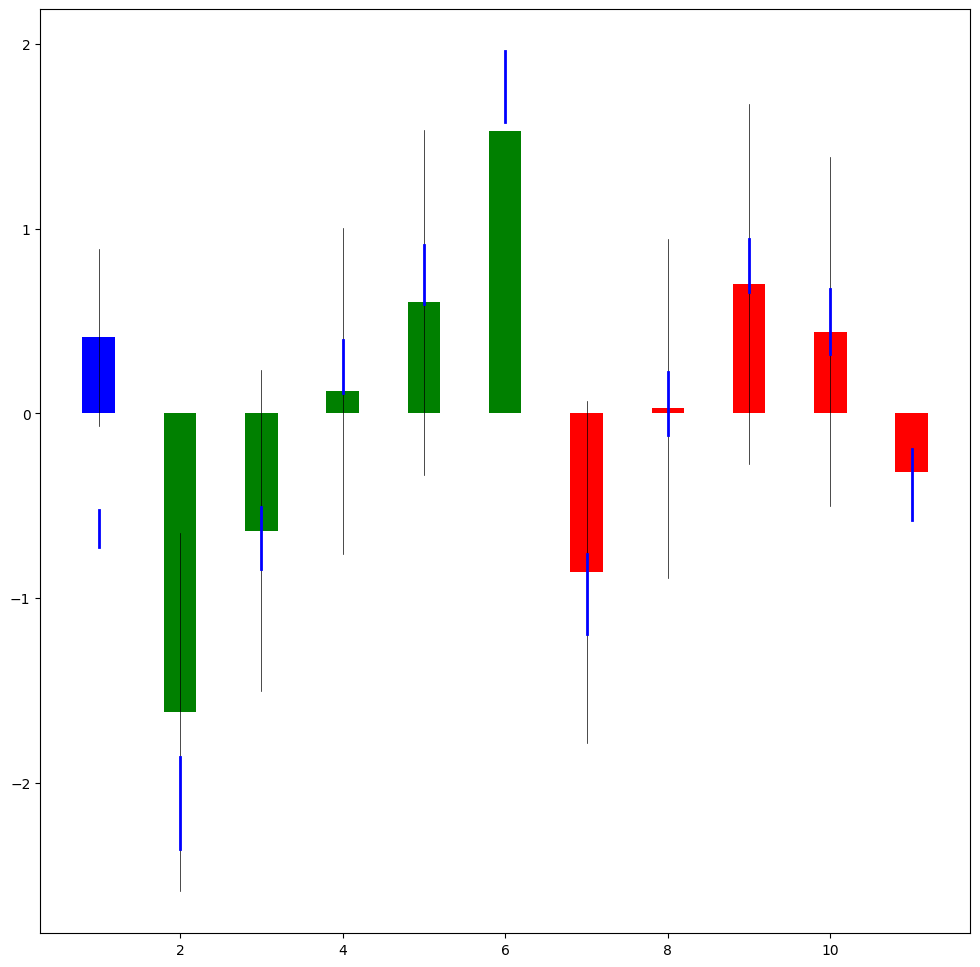

In [ ]:
# @title Logistic regression with bootstrap, cell infusion revisited {"vertical-output":true,"display-mode":"form"}
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import expit # logistic sigmoid function
from scipy.stats import binom

# define data
Nratio = 5;
Ntime  = 5;

thrived = np.array([
    [5,3,20,24,29],
    [15,36,43,56,66],
    [48,68,145,98,114],
    [29,35,57,38,72],
    [11,20,20,40,52]
])

colonies = np.array([
    [31,28,45,47,35],
    [77,78,71,71,74],
    [126,116,171,119,129],
    [92,52,85,50,77],
    [53,52,48,55,61]
])

design = np.array([
    [1,1,0,0,0,1,0,0,0],
    [1,0,1,0,0,1,0,0,0],
    [1,0,0,1,0,1,0,0,0],
    [1,0,0,0,1,1,0,0,0],
    [1,-1,-1,-1,-1,1,0,0,0],
    [1,1,0,0,0,0,1,0,0],
    [1,0,1,0,0,0,1,0,0],
    [1,0,0,1,0,0,1,0,0],
    [1,0,0,0,1,0,1,0,0],
    [1,-1,-1,-1,-1,0,1,0,0],
    [1,1,0,0,0,0,0,1,0],
    [1,0,1,0,0,0,0,1,0],
    [1,0,0,1,0,0,0,1,0],
    [1,0,0,0,1,0,0,1,0],
    [1,-1,-1,-1,-1,0,0,1,0],
    [1,1,0,0,0,0,0,0,1],
    [1,0,1,0,0,0,0,0,1],
    [1,0,0,1,0,0,0,0,1],
    [1,0,0,0,1,0,0,0,1],
    [1,-1,-1,-1,-1,0,0,0,1],
    [1,1,0,0,0,-1,-1,-1,-1],
    [1,0,1,0,0,-1,-1,-1,-1],
    [1,0,0,1,0,-1,-1,-1,-1],
    [1,0,0,0,1,-1,-1,-1,-1],
    [1,-1,-1,-1,-1,-1,-1,-1,-1]
])

def GetConfidenceRange( beta_patch ):

    [Nrepeat, Nbeta] = beta_patch.shape

    beta_low = np.zeros([1,Nbeta])
    beta_high = np.zeros([1,Nbeta])

    for k in range(Nbeta):
        beta_low[0,k] = np.quantile( beta_patch[:,k], 0.025 )
        beta_high[0,k] = np.quantile( beta_patch[:,k], 0.975 )

    return beta_low, beta_high
# collect matrix and observations

n = colonies.flatten()
X = design
y = thrived.flatten();

n_obs = n;
pi_obs = y / n;

# Negative log-likelihood for logistic regression
def neg_log_likelihood(beta, X, y, n):
 logits = X @ beta
 log_likelihood = y * logits - n * np.log(1 + np.exp(logits))
 return -np.sum(log_likelihood)

# Initial guess
beta_init = np.zeros(X.shape[1])

# Minimize negative log-likelihood
result = minimize(neg_log_likelihood, beta_init, args=(X, y, n), method='BFGS')

beta_fit = result.x;

logit_fit = X @ beta_fit
pi_fit = expit(logit_fit)

# Hessian variance of beta's ========================================

Varpi = pi_fit * (1 - pi_fit);   # variance

W = np.diag( Varpi );

Hessian = X.T @ W @ X;
Hessian_inv = np.linalg.inv(Hessian);    # inverse Hessian

var_beta = np.diag( Hessian_inv )

# Now repeat many times ========================================

Nrepeat = 500

beta_boot = np.zeros((Nrepeat, beta_fit.shape[0]))

beta_patch = np.zeros((Nrepeat, beta_fit.shape[0]+2))


for i in range(Nrepeat):

    thrived_boot = np.random.binomial(n=thrived, p=thrived/colonies, size=(5,5))

    y_boot = thrived_boot.flatten();

    result = minimize(neg_log_likelihood, beta_init, args=(X, y_boot, n), method='BFGS')

    beta_boot[i,:] = result.x;


# fill in non-fitted parameters from constraints

beta_patch[:,0]  =  beta_boot[:,0]
beta_patch[:,1]  =  beta_boot[:,1]
beta_patch[:,2]  =  beta_boot[:,2]
beta_patch[:,3]  =  beta_boot[:,3]
beta_patch[:,4]  =  beta_boot[:,4]
beta_patch[:,5]  = -beta_boot[:,1] - beta_boot[:,2] - beta_boot[:,3] - beta_boot[:,4]
beta_patch[:,6]  =  beta_boot[:,5]
beta_patch[:,7]  =  beta_boot[:,6]
beta_patch[:,8]  =  beta_boot[:,7]
beta_patch[:,9]  =  beta_boot[:,8]
beta_patch[:,10] = -beta_boot[:,5] - beta_boot[:,6] - beta_boot[:,7] - beta_boot[:,8]

# get confidence intervals
beta_low, beta_high = GetConfidenceRange( beta_patch )


# Output results ============================================
print( "Estimated pi's:", pi_fit.reshape(Nratio,Ntime) )

print("Estimated beta's:", beta_fit)

print("Upper bounds:\n", beta_low)

print("Lower bounds:\n", beta_high)


# Visualize results
fig = plt.figure( figsize=(12,12))

# Plot 1: Coefficients mu, alpha, beta
mu    = beta_fit[0]
alpha = beta_fit[1:5]   # four alphas
beta  = beta_fit[5:9]   # four betas
alphasum = np.sum(alpha)
betasum  = np.sum(beta)
alpha = np.append( alpha, -alphasum)  # fifth alpha
beta  = np.append( beta,  -betasum)   # fifth beta

# standard error from Hessian matrix
errmu = np.sqrt(var_beta[0])
erralpha = np.sqrt(var_beta[1:5])
errbeta = np.sqrt(var_beta[5:9])

# standard error from bootstrapping
mu_low = beta_low[0,0]
mu_high = beta_high[0,0]

alpha_low = beta_low[0,1:6]
alpha_high = beta_high[0,1:6]

beta_low = beta_low[0,6:11]
beta_high = beta_high[0,6:11]



labels = ['mu', 'alpha', 'beta']

plt.bar( [1], mu, width=0.4, color='blue', label='mu' )
plt.plot( [1,1], [mu-errmu,mu+errmu], color='black', linewidth=0.5)
plt.plot( [1,1], [mu_low,mu_high], color='blue', linewidth=2)

plt.bar( np.arange(2,7), alpha, width=0.4, color='green', label='alpha (time)' )
for i in range(4):
    plt.plot( [i+2,i+2], [alpha[i]-erralpha[i],alpha[i]+erralpha[i]], color='black', linewidth=0.5)
for i in range(5):
    plt.plot( [i+2,i+2], [alpha_low[i],alpha_high[i]], color='blue', linewidth=2)

plt.bar( np.arange(7,12), beta, width=0.4, color='red', label='beta (ratio)' )
for i in range(4):
    plt.plot( [i+7,i+7], [beta[i]-errbeta[i],beta[i]+errbeta[i]], color='black', linewidth=0.5)
for i in range(5):
    plt.plot( [i+7,i+7], [beta_low[i],beta_high[i]], color='blue', linewidth=2)








# **2. Shuffling for null distributions**

One of the most useful computer-based techniques is the generation of null distributions.

When we design a specific statistical summary of complex data (multiunit recordings, EEG recordings, fMRI signals, etc), we rarely have extensive prior experimence about the expected distribution under the null hypothesis. However, by selectively permuting those aspects of our data that pertain to our hypothesis, we can synthetically generate data under the null hypothesis. If we do this sufficiently often (10000 or so times), we can establish confidence limits under the null distribution, to which we can compare the statistic for the observed data.

<br>



# Dorsal and ventral area LIP

This following example is taken from the 2024 master thesis of Michelle Wirsum (Prof. Kristine Krug).

Michelle mapped the dorsal and ventral visual quadrants of area LIP (lateral intraparietal), collecting her results in the  'nifti' format. This format consists of a three dimensional volume of cortical voxels, with logical zeros and ones indicating whether a voxel does or does not belong to an area.

The volume size is $(256 \times 312 \times 200)$, with $15.974.400$ voxels in total.

A reference atlas lists $17.170$ voxels in either dorsal or ventral LIP.  Michelle's data identifies only $9.770$ voxels in either dorsal or ventral LIP.

<br>

The overlap $OL$ between reference and data arrays, $V_{ref}$ and $V_{data}$ can be computed in terms of 'geometric mean overlap'

$$
OL = \sqrt{\frac{\sum \left(V_{ref} \bigwedge V_{data}\right)}{\sum V_{ref}}\cdot \frac{\sum \left(V_{ref} \bigwedge V_{data}\right)}{\sum V_{data}}}
$$

where $\left(V_{ref} \bigwedge V_{data}\right)$ is a logical array indicating voxels in **both** volumes and $\sum V$ stands for the number of non-zero voxels in a volume.

<br>

The overlap computation provides

$$
OL_\mathit{dorsal} = 0.4001, \qquad OL_\mathit{ventral} = 0.5199
$$

How confident can we be in this result? Is the degree of overlap statistically significant for ventral and/or dorsal LIP?

# Shuffling the assignment


To determine significance, we can randomize the assignment of data voxels to dorsal or ventral LIP and for each randomization compute overlap with the atlas. This will provide us with a null distribution for overlap, which will reveal the significance (or otherwise) or Michelle's result.


<br>

Data volume (schematic) with two distinct sets of voxels labeled red or blue (on left) and another data volume where labeled voxels were randomly assigned to red or blue.

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/LIP_voxels_original.png" width="300">

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/LIP_voxels_mixed.png" width="300">

<br>

Comparison with the null distribution obtained by shuffling shows that the observed overlap is highly significant.





Mounted at /content/drive
Volume Depth: 256, Height: 312, Width: 200
Total Atlas voxels  : 17170
Total Parcellation voxels : 9770
Observed Overlap - Dorsal  : 0.4001
Observed Overlap - Ventral : 0.5199
Progress: 10/100
Progress: 20/100
Progress: 30/100
Progress: 40/100
Progress: 50/100
Progress: 60/100
Progress: 70/100
Progress: 80/100
Progress: 90/100
Progress: 100/100


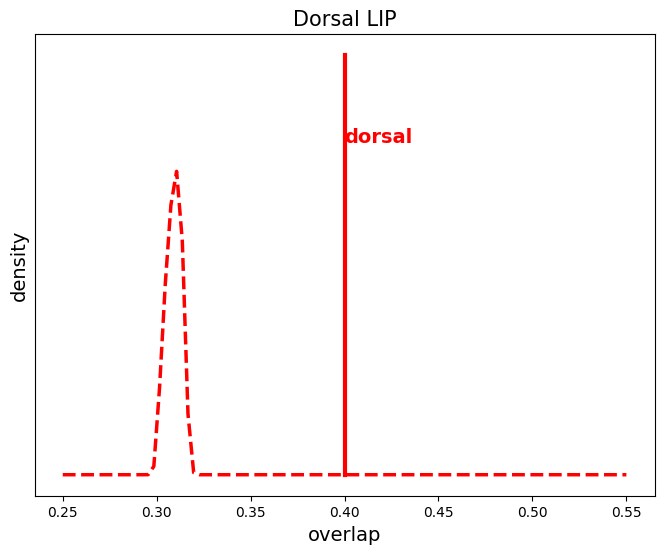

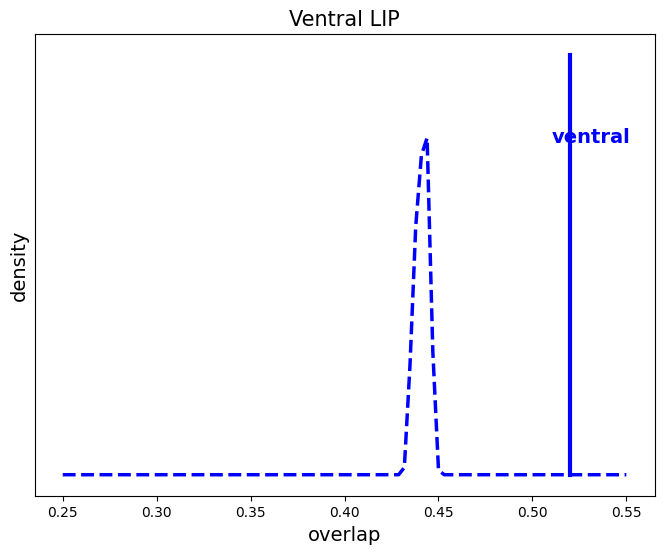

In [ ]:
# @title Dorsal and ventral LIP {"vertical-output":true,"display-mode":"form"}


# =============================================
# LIP Comparison - Google Colab Version
# =============================================

# Install required packages (run once)
!pip install -q nibabel matplotlib scipy numpy

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from google.colab import drive
drive.mount('/content/drive')

# Helper functions

def permute_voxels(VolA, VolB):
    """Permute labels between two regions (A and B)"""
    VolAB = VolA.astype(int) + 2 * VolB.astype(int)

    idx = np.nonzero(VolAB)
    oldvalue = VolAB[idx]

    p = np.random.permutation(len(oldvalue))
    newvalue = oldvalue[p]

    ShiftAB = np.zeros_like(VolAB)
    ShiftAB[idx] = newvalue

    ShiftA = (ShiftAB == 1)
    ShiftB = (ShiftAB == 2)

    return ShiftA, ShiftB


def get_overlap(VolA, VolB):
    """Compute geometric mean overlap"""
    VA = np.count_nonzero(VolA)
    VB = np.count_nonzero(VolB)
    VAUB = np.count_nonzero(VolA & VolB)

    if VA == 0 or VB == 0:
        return 0.0

    return np.sqrt((VAUB / VA) * (VAUB / VB))

# ============================
# Main Analysis
# ============================

# Load NIfTI files
LIPdAtlas = nib.load('/content/drive/MyDrive/Advanced Statistics/Data files/D99LIPd.l.bin.nii').get_fdata().astype(bool)
LIPvAtlas = nib.load('/content/drive/MyDrive/Advanced Statistics/Data files/D99LIPv.l.bin.nii').get_fdata().astype(bool)

LIPdParcel = nib.load('/content/drive/MyDrive/Advanced Statistics/Data files/LIPd.orient.l.t.c.nii').get_fdata().astype(bool)
LIPvParcel = nib.load('/content/drive/MyDrive/Advanced Statistics/Data files/LIPv.orient.l.t.c.nii').get_fdata().astype(bool)

# Basic statistics
TotalAtlas = np.count_nonzero(LIPdAtlas) + np.count_nonzero(LIPvAtlas)
TotalParcel = np.count_nonzero(LIPdParcel) + np.count_nonzero(LIPvParcel)

depth, height, width = LIPdAtlas.shape
print(f"Volume Depth: {depth}, Height: {height}, Width: {width}")

print(f"Total Atlas voxels  : {TotalAtlas}")
print(f"Total Parcellation voxels : {TotalParcel}")

# Observed overlaps
Odd = get_overlap(LIPdAtlas, LIPdParcel)
Ovv = get_overlap(LIPvAtlas, LIPvParcel)

print(f"Observed Overlap - Dorsal  : {Odd:.4f}")
print(f"Observed Overlap - Ventral : {Ovv:.4f}")

# ============================
# Null distribution (permutation test)
# ============================

Nshift = 100
Oddi = np.zeros(Nshift)
Ovvi = np.zeros(Nshift)

for i in range(Nshift):
    LIPdShifted, LIPvShifted = permute_voxels(LIPdParcel, LIPvParcel)

    Oddi[i] = get_overlap(LIPdAtlas, LIPdShifted)
    Ovvi[i] = get_overlap(LIPvAtlas, LIPvShifted)

    if (i + 1) % (Nshift/10) == 0:
        print(f"Progress: {i+1}/{Nshift}")

# ============================
# Plotting
# ============================

oi = np.linspace(0.25, 0.55, 100)

kde_d = gaussian_kde(Oddi)
kde_v = gaussian_kde(Ovvi)

fOdd = kde_d(oi)
fOvv = kde_v(oi)

plt.figure(figsize=(8, 6))

plt.plot(oi, fOdd, 'r--', linewidth=2.5, label='Dorsal null')
plt.plot([Odd, Odd], [0, 120], 'r', linewidth=3, label='Dorsal observed')

# Text labels like in MATLAB
plt.text(0.40, 95, 'dorsal', color='red', fontsize=14, fontweight='bold')

plt.xlabel('overlap', fontsize=14)
plt.ylabel('density', fontsize=14)
plt.title('Dorsal LIP', fontsize=15)

plt.gca().set_yticks([])
#plt.gca().set_aspect('equal', adjustable='box')


plt.show()

plt.figure(figsize=(8, 6))

plt.plot(oi, fOvv, 'b--', linewidth=2.5, label='Ventral null')
plt.plot([Ovv, Ovv], [0, 120], 'b', linewidth=3, label='Ventral observed')

# Text labels like in MATLAB
plt.text(0.51, 95, 'ventral', color='blue', fontsize=14, fontweight='bold')

plt.xlabel('overlap', fontsize=14)
plt.ylabel('density', fontsize=14)
plt.title('Ventral LIP', fontsize=15)

plt.gca().set_yticks([])
#plt.gca().set_aspect('equal', adjustable='box')


plt.show()



# Arrow-of-time irreversibility

Here I illustrate an application involving "arrow-of-time" irreversibility. Arrow-of-time refers to the fact that many physical systems develop in a manner that is asymmetric in time. (A dropped glass shatters on the floor, but a shattered glass never hops up from the floor and flies into your hand.) Other common terms for this are **irreversible flow** and **broken detailed balance**.


Often this irreversibility is simply due to an observable time-lag between cause and effect. For example, neural activity in the retina, the lateral geniculate, and primary visual cortex propagates with an observable delay, so that retinal activity consistently precedes lateral geniculate activity, which in turn consistently precedes primary visual cortex activity.

<br>

Consistent lags between two time-varying signals $x(t)$ and $y(t)$ are measured in terms of lagged correlations

$$
\rho(\tau) = \left\langle x(t) \cdot y(t+\tau)\right\rangle, \qquad\langle x(t)\rangle = \langle y(t)\rangle = 0, \qquad \langle x^2(t)\rangle = \langle y^2(t)\rangle = 1
$$

<br>

To quantify the degree of irreversibility, we convert correlation coefficients to mutual information (using the standard formula for normally distributed signals)

$$
I_m(\tau) =  -\frac{1}{2} \log \left[1 - \rho^2(\tau) \right]
$$


and form the squared difference between signed mutual information at positive and negative lags

$$
\mathrm{FowRev}(\tau) = \left[ I_\mathit{signed}(\tau) - I_\mathit{signed}(-\tau)\right]^2
$$

<br>

To obtain a scalar value, we integrate this difference over a suitable window of time $T_\mathit{shift}$

$$
\mathit{Asym} = \int_0^{T_\mathit{shift}} \mathrm{FowRev}(\tau) \, d\tau
$$

<br>

Refinement: if our timeseries exhibit both positive and negative correlations (at different lags), we should use a signed version of the mutual information

$$
I_\mathit{signed}(\tau) = I_m(\tau) \cdot \mathrm{sign}\left[ \rho(\tau) \right]
$$


<br>

This approach is quite recent and much easier to use than Granger causality. A good reference is:

[Broken detailed balance and entropy production in directed networks (2024) Phys. Rev. E.](https://journals.aps.org/pre/abstract/10.1103/PhysRevE.110.034313)


# Examples for strong and weak asymmetry

In the illustration below, the upper panels show four signal pairs (1288 time points each), two strongly asymmetric and two weakly asymmetric.

<br>

The lower panels show the lagged correlations $\rho(\tau)$ and the squared difference $\mathrm{FowRev}(\tau)$. Our measure of "arrow-of-time" asymmetry is the integral (area under the curve) integral.

<br>


<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_lagged_correlations.png" width="600">

<br>

# Null distribution

To generate a null distribution, the computation of "arrow-of-time" irreversibility values must be repreated many times with suitably randomized observations.

<br>

The relevant aspect for "arrow-of-time" irreversibility is the temporal alignment of the two time-varying signals, $x(t)$ and $y(t)$.
To randomize this alignment, we can shift one signal by some random time $T$

$$
y(t) \quad \to \quad y(t-T_\mathit{rand})
$$

However, we should be careful to avoid the interval $-T\leq \tau \leq T$ for which we compute irreversibility, so that we do not accidentally shift the signals back into alignment.

<br>

The code below uses

$$
2 T_\mathit{shift}\leq T_\mathit{rand} \leq  T_\mathit{signal} - 2 T_\mathit{shift}
$$

but any other interval will produce comparable results. The distribution of shuffled values is very close to zero, making our observed values **very highly significant**.

In [ ]:
# @title Arrow-of-time irreversibility, OU process example {"vertical-output":true,"display-mode":"form"}

import numpy as np
from ipywidgets import interact
import scipy.io
from scipy.stats import pearsonr
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

def OUinput(Ncause, Mu_li, Sigma, Tau, Ntimepoint ):
    """
    Generate Ornstein-Uhlenbeck process inputs.

    Parameters:
    Ncause: int, number of independent inputs
    Mu_li: float, mean, can vary over causes and time points
    Sigma: float, standard deviation
    Tau: float, autocovariance
    Ntimepoint: int, number of time points
    plotflag: bool, flag for plotting (not implemented)

    Returns:
    u_li: ndarray, generated OU process
    """

    # Initialize output array with NaNs
    u_li = np.full((Ncause, Ntimepoint), np.nan)

    # Generate random noise
    eta_li = np.random.normal(0, 1, (Ncause, Ntimepoint))

    # Set initial values
    u_li[:, 0] = np.random.normal(Mu_li[:,0], Sigma)

    # Calculate exponential factors
    efac1 = 1 - np.exp(-1/Tau)
    efac2 = np.sqrt(1 - np.exp(-2/Tau))

    # Generate OU process
    for i in range(1, Ntimepoint):
        u_li[:, i] = (u_li[:, i-1] +
                     (Mu_li[:,i] - u_li[:, i-1]) * efac1 +
                     Sigma * efac2 * eta_li[:, i])

    return u_li


def ShuffleDistribution( sA, sB, Nshift, Nshuffle ):

    Ntime = len( sA )

    Afr_s = np.zeros((Nshuffle, 1))

    for s in range(Nshuffle):

        shift = np.random.randint(2*Nshift, Ntime-2*Nshift)

        sS = np.roll(sB, -shift, axis=0)

        (ishift, cc_i, Afr_s[s]) = InsideoutCorrelation( sA, sS, Nshift )

        if np.mod(s,1000) == 0:
            print(s)

    return Afr_s


def InsideoutCorrelation( sA, sB, Nshift):

    ishift = np.arange(-Nshift, Nshift + 1)

    cc_i = np.zeros((Nshift * 2 + 1, 1))

    # Compute lagged correlation
    for i, shift in enumerate(ishift):
        # Positive shift correlates earlier values
        sS = np.roll(sB, -shift, axis=0)

        # Compute correlation
        cc_i[i] = np.corrcoef( sA.T, sS.T)[0,1]

    # Signed mutual information approximation
    #IM_i = -0.5 * np.sign(cc_i) * np.log(1 - cc_i ** 2)

    # Mutual information approximation
    IM_i = -0.5 * np.log(1 - cc_i ** 2)


    # Forward-reverse asymmetry
    ixpos = np.where(ishift > 0)[0]
    ixneg = np.where(ishift < 0)[0][::-1]

    fowrev_i = (IM_i[ixpos] - IM_i[ixneg]) ** 2

    # Replace infinities with 0
    fowrev_i[np.isinf(fowrev_i)] = 0

    # Average over shifts and scale
    fowrev = np.nansum(fowrev_i, axis=0)

    return ishift, cc_i, fowrev

# Example usage
def plot_shuffle_distribution( Ntimepoint, Causal_effect ):

     # set parameters

     Ncause = 1;
     Sigma = 1;
     Tau = 20;
     #Ntimepoint = 2000;
     t_i = np.arange(0,Ntimepoint);
     t_i = t_i.ravel()

     # generate process that is source of causal influence

     Mu_i = np.zeros((Ncause, Ntimepoint));

     u_i = OUinput(Ncause, Mu_i, Sigma, Tau, Ntimepoint );

     # generate process that is target of causal influence

     #strength =  2;

     v_i = OUinput(Ncause, Causal_effect * u_i, Sigma, Tau, Ntimepoint );

     u_i = u_i.ravel()
     v_i = v_i.ravel()

     plt.figure(figsize=(8, 4))
     plt.plot( t_i, u_i, 'r.', linewidth=1, label='u(t)' )
     plt.plot( t_i, v_i, 'b.', linewidth=1, label='v(t)' )
     plt.legend()
     plt.title("Two signals")
     plt.xlabel('time')
     plt.ylabel('u(t), s(t)')

     # InsideOut correlation



     Nshift = 50;

     (ishift, cc_uv_i, Afr_uv) = InsideoutCorrelation( u_i, v_i, Nshift)

     print( "Observed asymmetry:", Afr_uv )

     plt.figure(figsize=(8, 4))
     plt.plot( ishift, cc_uv_i, 'k-', linewidth=2 )
     plt.plot( -ishift, cc_uv_i, 'k:', linewidth=1 )
     plt.plot( [0,0], [-1,1], 'k:', linewidth=1 )
     plt.plot( [-Nshift,Nshift], [0,0], 'k:', linewidth=1 )
     titlestring = f"Lagged correlation, Irrev: {Afr_uv}"
     plt.xlim( -Nshift, Nshift)    # x from 0 to Nshift
     plt.ylim(-0.5, 1.0)      # y from -0.5 to 1.0
     plt.title( titlestring )
     plt.xlabel('lag')
     plt.ylabel('cc')

     shuffleflag = True

     if shuffleflag:

         Nshuffle = 1000

         Afr_uv_s = ShuffleDistribution(u_i, v_i, Nshift, Nshuffle )

         # 0.05 threshold
         Afr_thresh = np.quantile(Afr_uv_s, [0.95])

         # Afr range
         x_top = np.linspace(np.min(Afr_uv_s), np.max(Afr_uv_s), 100)

         # Plot smoothed historgrams of distribution
         kde_uv = gaussian_kde(Afr_uv_s.ravel())
         kde_uv_top = kde_uv(x_top)

         # alpha = 0.05 tail
         itail = np.where(x_top>Afr_thresh)[0]

         # x-values of tail (Python is maddening!)
         x_fill = x_top[itail]
         xbeg = np.atleast_1d((x_fill[0]))
         xend = np.atleast_1d((x_fill[-1]))
         x_fill = np.concatenate( [xbeg, x_fill.T, xend] )

         # y-values of tail
         kde_uv_fill = kde_uv_top[ itail ]
         kde_uv_fill = np.concatenate( [[0], kde_uv_fill.T, [0]] )

         plt.figure(figsize=(8, 6))
         plt.plot( x_top, kde_uv_top, color='black', linewidth=1, label='Shuffle' )
         plt.fill_between( x_fill, kde_uv_fill, color='red', label='Tail' )
         plt.plot( [Afr_uv, Afr_uv], [0,np.max(kde_uv_top)], 'r:', linewidth=2, label='Observed' )
         plt.title("Shuffle distribution and observed value")
         plt.legend()
         plt.xlabel('asym')
         plt.ylabel('Density')

         print( 'Causal effect:', Causal_effect )


interact( plot_shuffle_distribution, Ntimepoint = (1000,5000,1000), Causal_effect = (0.0,2.0,0.5) )




interactive(children=(IntSlider(value=3000, description='Ntimepoint', max=5000, min=1000, step=1000), FloatSli…

<function __main__.plot_shuffle_distribution(Ntimepoint, Causal_effect)>

# **4. Null distributions for entropy**

<br>

When computing measures of disorder or entropy, the shuffling approach faces some difficulties, because randomization typically inflates disorder or entropy.

<br>

To illustrate the problem, I use our recent study on changes of entropy production in resting-state EEG signals measured from adolescent females.

<br>

The recordings were performed by our colleagues in Budapest and the analysis was developed and carried out in Magdeburg.

<br>

[Szakacs, Mutlu, et al. 2024](https://advanced.onlinelibrary.wiley.com/doi/10.1002/advs.202308364)

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_adolescent_age_and_maturity.png" width="600">



# Entropy production by trajectory of EEG macrostates

We recorded high-density EEG from resting subjects, established whole-scalp phase coherence patterns at 100 Hz, and analyzed the development of such patterns over time. Even though these coherence patterns develop in a temporally continuous manner, the dynamics of whole-scalp coherence can be approximated in terms of a sequence of distinct macrostates. The resolution (level of detail) in this approximation depends on the chosen number of categorical states.

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_trajectory_sequence.png" width="800">


<br>

Panel a shows a representative trajectory of 128-dimensional microstates, projected into 3 dimensions. Sequence duration is 10 s (or 1000 microstates). Note that the trajectory moves largely continuously (in 10 ms steps). The apparent jumps (straight dotted lines) are computational artefacts owed to the ambiguity of eigenvector signs.

Panel b illustrates the same sequence in terms of categorical macrostates distinguished by color.



# Macrostate transitions

Having defined distinct "macrostates" (as categories or clusters of "microstates"), we established the statistics of macrostate 'transitions' for every recorded sequence of eigenvectors.  Consider an observed sequence of $N$ eigenvectors assigned to $K$ distinct clusters. For simplicity, we made sequences cyclical by pretending that the first vector succeeded the last vector. From every such sequence, we established transition counts $n^j_k$, that is, the observed number of transitions from cluster of origin $j$ to cluster of destination $k\neq j$.  

$$
n^j_k \quad \mathit{from} \,\, j \,\, \mathit{to} \,\,k, \qquad\qquad N_\mathit{trans} \equiv \sum_{k=1}^K \sum_{j\neq k} n^j_k
$$

where $N_\mathit{trans}$ is the total number of transitions . As any transition is *from* one state *to* another state, row and column sums in the matrices $n^j_k$ are equal

$$
\sum_k n^j_k = \sum_k n^k_j, \qquad\qquad \forall j
$$

<br>

Below is an example of an observed transition matrix. Note that this matrix is not exactly symmetric. This asymmetry could be accidental (due to the finite duration of the observed sequence) or it could be systematic (due to non-equilibrium dynamics of brain activity).

<br>

**We want to determine whether the observed degree of asymmetry is statistically significant!**

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/TransitionMatrixAsymmetric.png" width="400">

<br>



# Entropy production

The commonly used expression for entropy production in non-equilibrium systems [(Schnakenberg, 1976)](https://journals.aps.org/rmp/abstract/10.1103/RevModPhys.48.571) is the weighted sum of imbalanced flows


$$
\dot S_\mathit{tot} = \sum_{k\neq j} \left[ w^j_k P_j - w^k_j P_k \right] \log\frac{w^j_k P_j}{w^k_j P_k}
$$

where the sum is taken over all *unordered* pairs $k\neq j$.

Each unordered pair $k\neq j$ contributes

$$
\dot S_{jk} = \dot S_{kj} = \frac{n^j_k - n^k_j}{N} \log\frac{n^j_k}{n^k_j}
$$

to the total entropy production.

<br>

When no transitions are observed for a subset of ordered pairs $k\to j$, the associated transition flows vanish and the entropy production can be arbitrarily large. To avoid this issue, it is common to change the value of all $n^k_j=0$ to $n^k_j=1$. This arbitrary choice lowers entropy production and sets the numerical scale for its absolute value. Due to this arbitrary choice, only the relative values of entropy production are meaningful and interpretable.



# Flow ratio

To avoid the issue of singularities, we use the **flow ratio** instead of entropy production.

The sum of the observed **net flows** is


$$
\dot F_\mathit{net}  = \sum_{k\neq j} \left| n^j_k  - n^k_j \right|
$$

where the sum is taken over all *unordered* pairs $k\neq j$.

Similarly, the sum of the observed **total flows** is

$$
F_\mathit{total}  = \sum_{k\neq j} \left( n^j_k  + n^k_j \right)
$$

<br>

The flow ratio is then defined as

$$
FR = \frac{F_\mathit{net}}{F_\mathit{total}}
$$


In [ ]:
# @title Bootstrapping flow ratios, the wrong way {"vertical-output":true,"display-mode":"form"}

import numpy as np
from ipywidgets import interact
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import gaussian_kde
from scipy.interpolate import interp1d
from scipy.special import gamma, beta, hyp2f1

def TransitionMatrix():

    Tjk = np.array([
         [0, 1, 5, 29, 1, 1, 7, 35, 74, 28, 3, 30],
         [3, 0, 0, 4, 24, 48, 17, 3, 1, 9, 60, 2],
         [5, 0, 0, 19, 51, 0, 20, 0, 40, 4, 17, 2],
         [30, 2, 16, 0, 0, 1, 14, 56, 36, 25, 1, 16],
         [2, 22, 45, 2, 0, 70, 0, 0, 3, 7, 43, 22],
         [2, 46, 3, 2, 79, 0, 14, 78, 0, 1, 3, 57],
         [10, 19, 14, 12, 2, 19, 0, 23, 1, 6, 1, 1],
         [29, 2, 0, 47, 0, 86, 29, 0, 0, 1, 1, 43],
         [78, 0, 48, 34, 2, 0, 0, 1, 0, 22, 95, 0],
         [22, 10, 3, 32, 1, 0, 6, 2, 41, 0, 37, 41],
         [1, 66, 19, 2, 42, 5, 0, 0, 84, 42, 0, 0],
         [32, 3, 5, 14, 14, 55, 1, 40, 0, 50, 0, 0]
    ])

    return Tjk

def GetFlowRatioValue(Tij):
    """
    Compute an flow ratio value from a transition count matrix Tij.

    Parameters:
    Tij : 2D NumPy array, transition count matrix

    Returns:
    hval : float, computed entropy value
    """
    # Validate input
    if not isinstance(Tij, np.ndarray) or Tij.ndim != 2:
        raise ValueError("Tij must be a 2D NumPy array.")

    # Compute Tij' (transpose of Pij)
    Tij_transpose = Tij.T

    # Compute element-wise difference and sum
    flow_diff = np.abs( Tij - Tij_transpose )

    flow_sum  = np.abs( Tij + Tij_transpose )

    # Sum all elements
    FR = np.sum(flow_diff) / np.sum(flow_sum)

    return FR

def GetTransitionCounts(Ncluster, sequence):
    """
    Compute transition count matrix from a state sequence.

    Parameters:
    Ncluster : int, number of states
    sequence : array-like, sequence of state indices (1-based)

    Returns:
    Tij : 2D array, transition count matrix
    """
    Tij = np.zeros((Ncluster, Ncluster))
    sequence = np.array(sequence, dtype=int) - 1  # Convert to 0-based
    for i in range(len(sequence) - 1):
        current_state = sequence[i]
        next_state = sequence[i + 1]
        if 0 <= current_state < Ncluster and 0 <= next_state < Ncluster:
            Tij[current_state, next_state] += 1
    return Tij


def BootstrapFlowRatio(Tij, Nsequence, Nbootstrap):
    """
    Simulate a DTMC and compute bootstrap entropy estimates.

    Parameters:
    Tij : 2D array, transition count matrix (Ncluster x Ncluster)
    Nsequence : int, length of each bootstrap sequence
    Nbootstrap : int, number of bootstrap iterations

    Returns:
    Hbs : array, entropy values for each bootstrap sample
    """
    # Get number of clusters
    Ncluster = Tij.shape[0]

    # Compute transition probabilities Pitoj
    Pitoj = np.zeros((Ncluster, Ncluster))
    row_sums = np.sum(Tij, axis=1, keepdims=True)
    Pitoj = Tij / row_sums;

    # Compute overall state probabilities Pi
    Pi = np.sum(Tij, axis=1) / np.sum(Tij)

    # Initialize bootstrap arrays
    bsID = np.full(Nsequence, np.nan)  # State sequence
    FRbs  = np.full(Nbootstrap, np.nan)  # Entropy values

    # Bootstrap iterations
    for k in range(Nbootstrap):
        # Initialize sequence with first state
        bsID[0] = NextID(Pi)

        # Generate sequence
        for j in range(1, Nsequence):
            iid = int(bsID[j-1] - 1)  # Convert to 0-based for Python
            nid = NextID(Pitoj[iid, :])
            bsID[j] = nid

        # Compute transition counts for bootstrap sequence
        bsTij = GetTransitionCounts(Ncluster, bsID)

        # Compute entropy
        FRbs[k] = GetFlowRatioValue(bsTij)

        # Progress update
        if (k + 1) % 100 == 0:
            print(f"[Bootstrap {k + 1}/{Nbootstrap}]")

    return FRbs

def NextID(Pi):
    """
    Sample a state index based on a probability distribution using inverse transform sampling.

    Parameters:
    Pi : array-like, probability distribution over states (non-negative, sums to ~1)

    Returns:
    iid : int, sampled state index (1-based to match MATLAB)
    """
    # Convert input to numpy array and normalize
    Pi = np.array(Pi, dtype=float)
    if np.any(Pi < 0):
        raise ValueError("Probabilities must be non-negative.")
    if np.sum(Pi) == 0:
        raise ValueError("Probability distribution cannot be all zeros.")
    Pi = Pi / np.sum(Pi)  # Normalize to sum to 1

    # Generate a random number in [0, 1]
    rand_val = np.random.random()

    # Compute cumulative sum of probabilities
    cumsum_Pi = np.cumsum(Pi)

    # Find the first index where rand <= cumsum(Pi)
    idx = rand_val <= cumsum_Pi

    # Find the first True index (equivalent to MATLAB's find(idx==1))
    ix = np.where(idx)[0]

    if len(ix) == 0:
        raise RuntimeError("No valid index found (possible numerical issue).")

    # Take the first index (1-based to match MATLAB)
    iid = ix[0] + 1

    return iid

# Example usage
def plot_observed_and_bootstrapped_flow_ratio( Nbootstrap=500, Nsequence=5000 ):

    # observed transition matrix
    Tij = TransitionMatrix();

    print(f"Observed Sequence length: {Nsequence}")

    # observed entropy value

    FRobs = GetFlowRatioValue(Tij)

    print(f"Observed Flow Ratio: {FRobs:.4f}")

    Nbootstrap = 500

    # Run bootstrap flow ratio estimation
    FRbs = BootstrapFlowRatio(Tij, Nsequence, Nbootstrap)

    # Smoothed histogram of distribution
    kde = gaussian_kde(FRbs)
    h = np.linspace(0, np.max(FRbs), 200)

    kde_values = kde(h)

    # Print summary
    print(f"Mean Flow Ratio: {np.mean(FRbs):.4f}")
    print(f"Std Flow Ratio: {np.std(FRbs, ddof=1):.4f}")

    # Plot histogram of entropy values
    plt.figure(figsize=(8, 6))
    plt.hist(FRbs, bins=50, density=True, alpha=0.6, label='Bootstrapped')
    plt.plot(h, kde_values, 'r:', linewidth=2, label='KDE')
    plt.plot([FRobs,FRobs], [0,np.max(kde_values)], 'r', linewidth=2, label='Observed')
    plt.xlabel('Entropy')
    plt.ylabel('Density')
    plt.title('Observed and Bootstrapped Flow Ratio Values')

    plt.legend()

    plt.show()

    return;

interact( plot_observed_and_bootstrapped_flow_ratio, Nsequence = (5000, 50000, 45000), Nbootstrap = (500, 5000, 500) )



interactive(children=(IntSlider(value=500, description='Nbootstrap', max=5000, min=500, step=500), IntSlider(v…

<function __main__.plot_observed_and_bootstrapped_flow_ratio(Nbootstrap=500, Nsequence=5000)>

# Bootstrapping flow ratios the right way

We find that bootstrapped flow ratio values are distributed **to the right** of our observed value. This is a suprise, as we would expect bootstrapped values to distribute on both sides (**left and right**) of the observed value.

<br>

The problem stems from the finite length of the observed trajectory. As we generate very long synthetic trajectories, the entropy value approaches the observed value, demonstrating that our bootstrapping procedure works.

<br>

Evidently, generating trajectories of finite length introduces noise, which contributes spurious asymmetry and inflates the bootstrapped values. How much noise does a trajectory of a certain length contribute?

<br>

We can answer this empirically, by generating trajectories from a symmetric matrix, for which the theoretical entropy production is exactly zero. Accordingly, any entropy production that we observe for a symmetric matrix must be due to noise.

<br>

The average amount of spuriously produced entropy can then be used to correct (left-shift) our boostrapped distributions.

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/TransitionMatrixAsymmetric.png" width="400">
$\qquad\qquad$
<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/TransitionMatrixSymmetric.png" width="400">

<br>

**In this way, we can establish the statistical significance of our observed entropy value.**





In [ ]:
# @title Bootstrapping flow ratios, the right way {"vertical-output":true,"display-mode":"form"}

import numpy as np
from ipywidgets import interact
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import gaussian_kde
from scipy.interpolate import interp1d
from scipy.special import gamma, beta, hyp2f1

def TransitionMatrix():

    Tjk = np.array([
         [0, 1, 5, 29, 1, 1, 7, 35, 74, 28, 3, 30],
         [3, 0, 0, 4, 24, 48, 17, 3, 1, 9, 60, 2],
         [5, 0, 0, 19, 51, 0, 20, 0, 40, 4, 17, 2],
         [30, 2, 16, 0, 0, 1, 14, 56, 36, 25, 1, 16],
         [2, 22, 45, 2, 0, 70, 0, 0, 3, 7, 43, 22],
         [2, 46, 3, 2, 79, 0, 14, 78, 0, 1, 3, 57],
         [10, 19, 14, 12, 2, 19, 0, 23, 1, 6, 1, 1],
         [29, 2, 0, 47, 0, 86, 29, 0, 0, 1, 1, 43],
         [78, 0, 48, 34, 2, 0, 0, 1, 0, 22, 95, 0],
         [22, 10, 3, 32, 1, 0, 6, 2, 41, 0, 37, 41],
         [1, 66, 19, 2, 42, 5, 0, 0, 84, 42, 0, 0],
         [32, 3, 5, 14, 14, 55, 1, 40, 0, 50, 0, 0]
    ])

    return Tjk

def GetFlowRatioValue(Tij):
    """
    Compute an flow ratio value from a transition count matrix Tij.

    Parameters:
    Tij : 2D NumPy array, transition count matrix

    Returns:
    hval : float, computed entropy value
    """
    # Validate input
    if not isinstance(Tij, np.ndarray) or Tij.ndim != 2:
        raise ValueError("Tij must be a 2D NumPy array.")

    # Compute Tij' (transpose of Pij)
    Tij_transpose = Tij.T

    # Compute element-wise difference and sum
    flow_diff = np.abs( Tij - Tij_transpose )

    flow_sum  = np.abs( Tij + Tij_transpose )

    # Sum all elements
    FR = np.sum(flow_diff) / np.sum(flow_sum)

    return FR

def GetTransitionCounts(Ncluster, sequence):
    """
    Compute transition count matrix from a state sequence.

    Parameters:
    Ncluster : int, number of states
    sequence : array-like, sequence of state indices (1-based)

    Returns:
    Tij : 2D array, transition count matrix
    """
    Tij = np.zeros((Ncluster, Ncluster))
    sequence = np.array(sequence, dtype=int) - 1  # Convert to 0-based
    for i in range(len(sequence) - 1):
        current_state = sequence[i]
        next_state = sequence[i + 1]
        if 0 <= current_state < Ncluster and 0 <= next_state < Ncluster:
            Tij[current_state, next_state] += 1
    return Tij


def BootstrapFlowRatio(Tij, Nsequence, Nbootstrap):
    """
    Simulate a DTMC and compute bootstrap entropy estimates.

    Parameters:
    Tij : 2D array, transition count matrix (Ncluster x Ncluster)
    Nsequence : int, length of each bootstrap sequence
    Nbootstrap : int, number of bootstrap iterations

    Returns:
    Hbs : array, entropy values for each bootstrap sample
    """
    # Get number of clusters
    Ncluster = Tij.shape[0]

    # Compute transition probabilities Pitoj
    Pitoj = np.zeros((Ncluster, Ncluster))
    row_sums = np.sum(Tij, axis=1, keepdims=True)
    Pitoj = Tij / row_sums;

    # Compute overall state probabilities Pi
    Pi = np.sum(Tij, axis=1) / np.sum(Tij)

    # Initialize bootstrap arrays
    bsID = np.full(Nsequence, np.nan)  # State sequence
    FRbs  = np.full(Nbootstrap, np.nan)  # Entropy values

    # Bootstrap iterations
    for k in range(Nbootstrap):
        # Initialize sequence with first state
        bsID[0] = NextID(Pi)

        # Generate sequence
        for j in range(1, Nsequence):
            iid = int(bsID[j-1] - 1)  # Convert to 0-based for Python
            nid = NextID(Pitoj[iid, :])
            bsID[j] = nid

        # Compute transition counts for bootstrap sequence
        bsTij = GetTransitionCounts(Ncluster, bsID)

        # Compute entropy
        FRbs[k] = GetFlowRatioValue(bsTij)

        # Progress update
        if (k + 1) % 100 == 0:
            print(f"[Bootstrap {k + 1}/{Nbootstrap}]")

    return FRbs

def NextID(Pi):
    """
    Sample a state index based on a probability distribution using inverse transform sampling.

    Parameters:
    Pi : array-like, probability distribution over states (non-negative, sums to ~1)

    Returns:
    iid : int, sampled state index (1-based to match MATLAB)
    """
    # Convert input to numpy array and normalize
    Pi = np.array(Pi, dtype=float)
    if np.any(Pi < 0):
        raise ValueError("Probabilities must be non-negative.")
    if np.sum(Pi) == 0:
        raise ValueError("Probability distribution cannot be all zeros.")
    Pi = Pi / np.sum(Pi)  # Normalize to sum to 1

    # Generate a random number in [0, 1]
    rand_val = np.random.random()

    # Compute cumulative sum of probabilities
    cumsum_Pi = np.cumsum(Pi)

    # Find the first index where rand <= cumsum(Pi)
    idx = rand_val <= cumsum_Pi

    # Find the first True index (equivalent to MATLAB's find(idx==1))
    ix = np.where(idx)[0]

    if len(ix) == 0:
        raise RuntimeError("No valid index found (possible numerical issue).")

    # Take the first index (1-based to match MATLAB)
    iid = ix[0] + 1

    return iid

# Example usage
def plot_observed_and_corrected_bootstrap( Nbootstrap=500 ):

    # observed transition matrix
    Tij_asym = TransitionMatrix();

    Nsequence = np.sum(Tij_asym)

    print(f"Observed Sequence length: {Nsequence}")

    # observed entropy value

    FRobs = GetFlowRatioValue(Tij_asym)

    print(f"Observed Entropy: {FRobs:.4f}")

    # Run bootstrap entropy estimation
    FRbs_asym = BootstrapFlowRatio(Tij_asym, Nsequence, Nbootstrap)

    # Symmetric transition matrix
    Tij_sym = ( Tij_asym + Tij_asym.T ) / 2;

    FRbs_sym = BootstrapFlowRatio(Tij_sym, Nsequence, Nbootstrap)

    # Smoothed histogram of asymmetric distribution
    kde_asym = gaussian_kde(FRbs_asym)
    fr_asym = np.linspace(0, np.max(FRbs_asym), 200)
    kde_asym_values = kde_asym(fr_asym)

    # Smoothes histogram of symmetric distribution
    kde_sym = gaussian_kde(FRbs_sym)
    fr_sym = np.linspace(0, np.max(FRbs_sym), 200)
    kde_sym_values = kde_sym(fr_sym)

    # Left-shift for correction
    fr_shift = np.mean(FRbs_sym)
    fr_corr_asym = fr_asym - fr_shift
    fr_corr_sym = fr_sym - fr_shift

    # Print summary
    print(f"Mean Flow Ratio: {np.mean(FRbs_asym):.4f}")
    print(f"Std Entropy: {np.std(FRbs_asym, ddof=1):.4f}")

    # Plot histogram of flow ratio values
    plt.figure(figsize=(8, 6))
    plt.plot(fr_corr_sym, kde_sym_values, 'k:', linewidth=2, label='Symmmetric')
    plt.plot(fr_corr_asym, kde_asym_values, 'r:', linewidth=2, label='Asymmetric')
    plt.plot([0,0], [0,np.max(kde_sym_values)], 'k', linewidth=2, label='Observed')
    plt.plot([FRobs,FRobs], [0,np.max(kde_sym_values)], 'r', linewidth=2, label='Observed')
    plt.xlabel('Entropy')
    plt.ylabel('Density')
    plt.title('Observed and Bootstrapped Entropy Values, AFTER correction')

    plt.legend()

    plt.show()

    return;

interact( plot_observed_and_corrected_bootstrap, Nbootstrap = (500, 5000, 500) )



interactive(children=(IntSlider(value=500, description='Nbootstrap', max=5000, min=500, step=500), Output()), …

<function __main__.plot_observed_and_corrected_bootstrap(Nbootstrap=500)>

# **Summary**

This figure summarizes the corrections that are required for bootstrapping entropy production.

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_entropy_production.png" width="800">

<br>

# **Summary**

**1. Bootstrapping for standard error and confidence**

**2. Bootstrapping standard errors in logistic regression**

**3. Shuffling for null distributions**

**4. Null distribuitions for entropy**

<br>

# **Remaining lectures**



**Lecture 11: Linear discriminant analysis (Jochen Braun)**

**Lecture 12: Multivariate LDA (Jochen Braun)**